### Installing Dependencies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import(accuracy_score, classification_report,confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay)

### Load Dataset

In [2]:
df = pd.read_csv('intention_dataset.csv')
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


### Basic EDA

In [3]:
print("Missing Values:\n")
print(df.isnull().sum())

print("\nDuplicates:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)

Missing Values:

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

Duplicates: 125


In [4]:
print('Duplicates after removal:',df.duplicated().sum())

Duplicates after removal: 0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12205 entries, 0 to 12204
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12205 non-null  int64  
 1   Administrative_Duration  12205 non-null  float64
 2   Informational            12205 non-null  int64  
 3   Informational_Duration   12205 non-null  float64
 4   ProductRelated           12205 non-null  int64  
 5   ProductRelated_Duration  12205 non-null  float64
 6   BounceRates              12205 non-null  float64
 7   ExitRates                12205 non-null  float64
 8   PageValues               12205 non-null  float64
 9   SpecialDay               12205 non-null  float64
 10  Month                    12205 non-null  object 
 11  OperatingSystems         12205 non-null  int64  
 12  Browser                  12205 non-null  int64  
 13  Region                   12205 non-null  int64  
 14  TrafficType           

In [6]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000
mean,2.338878,81.646331,0.508726,34.825454,32.045637,1206.982457,0.020370,0.041466,5.949574,0.061942,2.124211,2.357804,3.153298,4.073904
std,3.330436,177.491845,1.275617,141.424807,44.593649,1919.601400,0.045255,0.046163,18.653671,0.199666,0.906823,1.710114,2.402340,4.016654
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,8.000000,193.000000,0.000000,0.014231,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,9.000000,0.000000,0.000000,18.000000,608.942857,0.002899,0.025000,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,94.700000,0.000000,0.000000,38.000000,1477.154762,0.016667,0.048529,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


### Class Distribution

In [7]:
df['Revenue'] = df['Revenue'].astype(int)

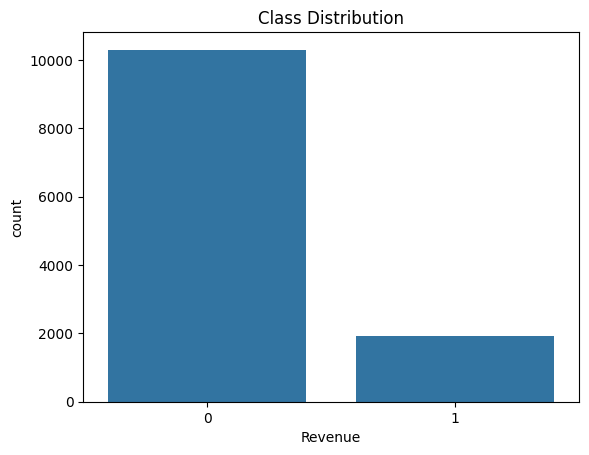

In [8]:
sns.countplot(x='Revenue',data=df)
plt.title('Class Distribution')
plt.show()

In [9]:
df = pd.get_dummies(df,drop_first=True)

### Split Data

In [11]:
X = df.drop('Revenue',axis=1)
y = df['Revenue']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)


### Scale Data

In [12]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Model tuning function

In [13]:
def tune_model(model,param_grid):
    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=5,
        verbose=1,
        n_jobs=-1
    )

    grid.fit(X_train,y_train)
    best_model = grid.best_estimator_

    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:,1]

    print('Model:',model.__class__.__name__)
    print('Best Params:',grid.best_params_)
    print('Accuracy:',accuracy_score(y_test,y_pred))
    print('\nClassification Report:\n',classification_report(y_test,y_pred))
    print('ROC AUC:',roc_auc_score(y_test,y_proba))

    print('='*50)
    return best_model

### Parameter grids

In [14]:
logistic_params = {
    'C':[0.01,0.1,1,10]
}

decision_tree_params = {
    'max_depth':[None, 10,20],
    'min_samples_split':[2,5,10]
}

random_forest_params = {
    'n_estimators':[100,200],
    'max_depth':[None,10]
}

In [15]:
best_lr = tune_model(LogisticRegression(max_iter=1000),logistic_params)

best_dt = tune_model(DecisionTreeClassifier(),decision_tree_params)

best_rf = tune_model(RandomForestClassifier(),random_forest_params)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Model: LogisticRegression
Best Params: {'C': 1}
Accuracy: 0.889389594428513

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.98      0.94      2059
           1       0.77      0.42      0.54       382

    accuracy                           0.89      2441
   macro avg       0.84      0.70      0.74      2441
weighted avg       0.88      0.89      0.88      2441

ROC AUC: 0.9022691847056341
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Model: DecisionTreeClassifier
Best Params: {'max_depth': 10, 'min_samples_split': 10}
Accuracy: 0.8881605899221631

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.94      0.93      2059
           1       0.65      0.62      0.63       382

    accuracy                           0.89      2441
   macro avg       0.79      0.78      0.78      2441
weighted avg

### Select best model

In [16]:
models = {
    'Logistic Regression':best_lr,
    'Decision Tree': best_dt,
    'Random Forest': best_rf
}

best_model = None
best_score = 0

for name,model in models.items():
    y_prob = model.predict_proba(X_test)[:,1]
    score = roc_auc_score(y_test,y_prob)
    print(f'{name} ROC-AUC:',score)

    if score > best_score:
        best_score = score
        best_model = model

print('\nBest Model:',best_model)

Logistic Regression ROC-AUC: 0.9022691847056341
Decision Tree ROC-AUC: 0.8838854575366988
Random Forest ROC-AUC: 0.9334119902662046

Best Model: RandomForestClassifier(max_depth=10)


### Confusion matrix

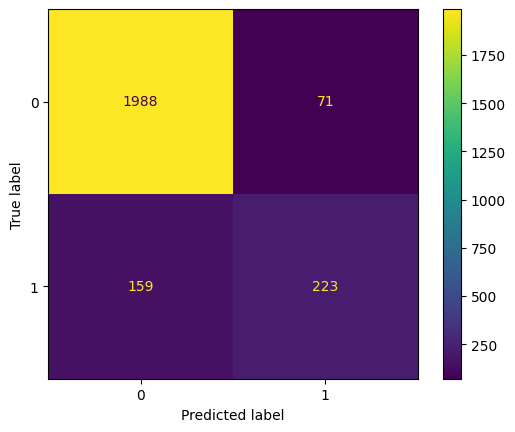

In [17]:
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

### ROC Curve

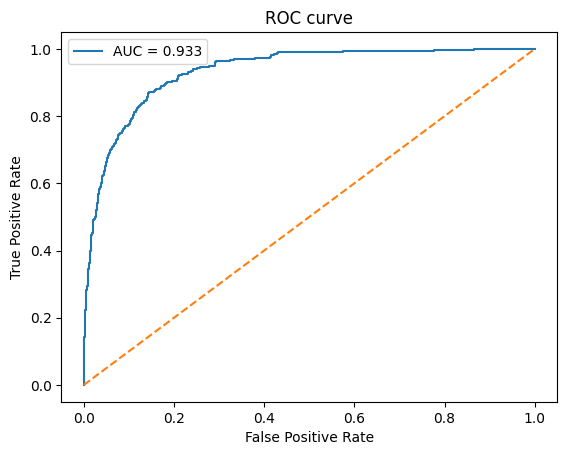

In [18]:
y_prob = best_model.predict_proba(X_test)[:,1]

fpr,tpr,thresholds = roc_curve(y_test,y_prob)
auc_score = roc_auc_score(y_test,y_prob)

plt.plot(fpr,tpr,label=f'AUC = {auc_score:.3f}')
plt.plot([0,1],[0,1],'--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC curve')
plt.legend()
plt.show()

### Feature importance

In [19]:
if hasattr(best_model, "feature_importances_"):
    
    feature_importance = best_model.feature_importances_

    imp_df = pd.DataFrame({
        'feature': X.columns,
        'importance': feature_importance
    }).sort_values(by='importance', ascending=False)

    imp_df.head(10)
    
else:
    print("Feature importance not available for this model")

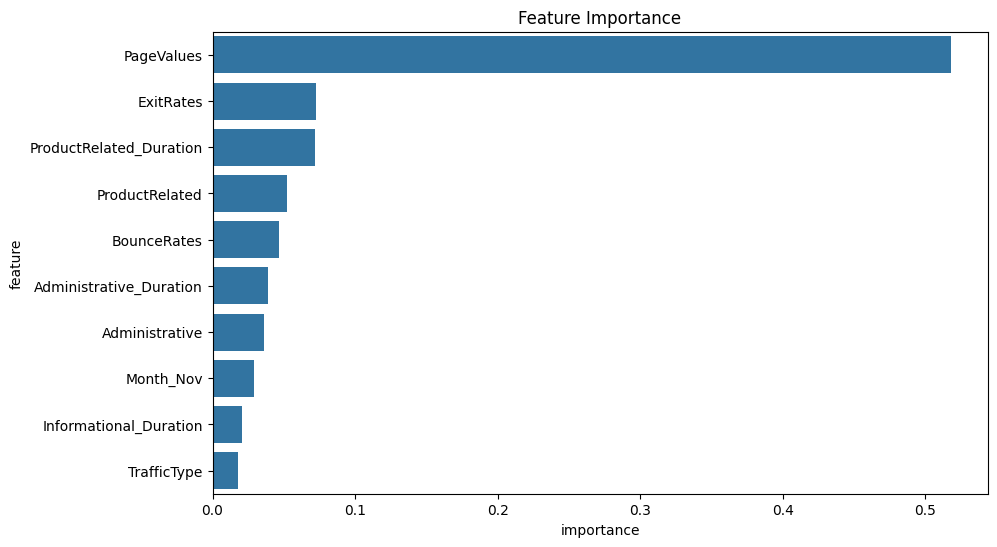

In [20]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='importance',
    y='feature',
    data=imp_df.head(10)
)
plt.title('Feature Importance')
plt.show()

In [21]:
joblib.dump(best_model,'best_model.pkl')

['best_model.pkl']

### Deep Learning (ANN) 

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

In [23]:
early_stop = EarlyStopping(
    patience=3,
    restore_best_weights=True
)

In [24]:
dl_model = Sequential()

dl_model.add(Input(shape=(X_train.shape[1],)))

dl_model.add(Dense(64,activation='relu'))
dl_model.add(Dropout(0.3))

dl_model.add(Dense(32,activation='relu'))
dl_model.add(Dropout(0.3))

dl_model.add(Dense(1,activation='sigmoid'))

dl_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [25]:
history = dl_model.fit(
    X_train,y_train,epochs=20,batch_size=32,validation_split=0.2,callbacks=[early_stop]
)

Epoch 1/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8478 - loss: 0.3845 - val_accuracy: 0.8756 - val_loss: 0.2954
Epoch 2/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8767 - loss: 0.3039 - val_accuracy: 0.8827 - val_loss: 0.2761
Epoch 3/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8853 - loss: 0.2842 - val_accuracy: 0.8884 - val_loss: 0.2647
Epoch 4/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8868 - loss: 0.2764 - val_accuracy: 0.8904 - val_loss: 0.2639
Epoch 5/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8927 - loss: 0.2675 - val_accuracy: 0.8920 - val_loss: 0.2600
Epoch 6/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8935 - loss: 0.2655 - val_accuracy: 0.8920 - val_loss: 0.2571
Epoch 7/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8930 - loss: 0.2567 - val_accuracy: 0.8950 - val_loss: 0.2630
Epoch 8/20
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8951 - loss: 0.2529 - val_accuracy: 0.

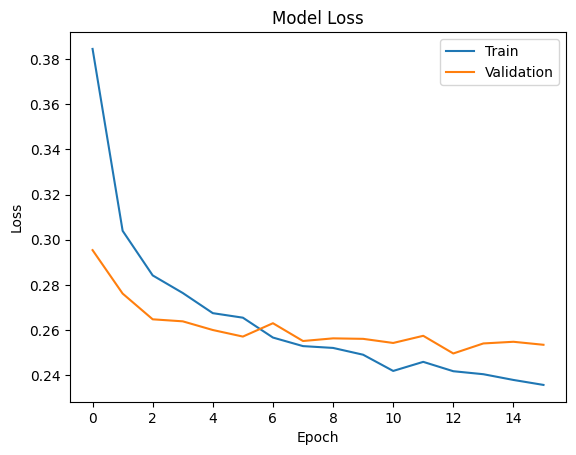

In [26]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

In [27]:
y_pred_dl = (dl_model.predict(X_test) > 0.5).astype('int32')
print(classification_report(y_test,y_pred_dl))

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      2059
           1       0.68      0.63      0.66       382

    accuracy                           0.90      2441
   macro avg       0.81      0.79      0.80      2441
weighted avg       0.89      0.90      0.90      2441

